# 01. EDA
## 목적
공업사에서 수집한 배터리 데이터 확인 및 특성 파악

In [2]:
import pandas as pd

In [4]:
df = pd.read_excel("../data/_Work_/_Work_battery_.xlsx")

In [5]:
df.head()

,날짜,차량,배터리 종류,전압(V),내부저항(mΩ),SOH(%),CCA(A),RC(min),교체 여부,메모,증상,테스트 결과
0,2026-06-26,벤츠orQM6/2017,AtlasBX \nLN4,NaN,NaN,NaN,NaN,NaN,O,AtlasBX 80Ah 800CCA,"시동불량,\n전압 저하",NaN
1,2026-06-29,미상,AtlasBX \nLN4,12.91,5.89,26.0,459.0,NaN,O,AtlasBX 80Ah 800CCA,NaN,교체바람
2,2026-06-30,미상(휴즈),NaN,NaN,NaN,NaN,NaN,NaN,O,NaN,NaN,NaN
3,2026-07-03,하이브리드,NaN,NaN,NaN,NaN,NaN,NaN,O,NaN,NaN,NaN
4,2026-07-07,스타렉스,Rocket\nGB90R,11.58,26.11,0.0,103.0,160 min\n(기본 값),O,Rocket\nGB90R\n90Ah\n160 min\n710A,NaN,"극판손상, \n교체 후\n 14.4V"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   날짜        13 non-null     datetime64[ns]
 1   차량        13 non-null     object        
 2   배터리 종류    10 non-null     object        
 3   전압(V)     9 non-null      float64       
 4   내부저항(mΩ)  9 non-null      float64       
 5   SOH(%)    9 non-null      float64       
 6   CCA(A)    9 non-null      float64       
 7   RC(min)   2 non-null      object        
 8   교체 여부     13 non-null     object        
 9   메모        8 non-null      object        
 10  증상        2 non-null      object        
 11  테스트 결과    9 non-null      object        
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 1.3+ KB


In [7]:
df.describe()

,날짜,전압(V),내부저항(mΩ),SOH(%),CCA(A)
count,13,9.000000,9.000000,9.000000,9.000000
mean,2026-07-11 01:50:46.153846272,11.575556,20.205556,27.777778,355.777778
min,2026-06-26 00:00:00,6.680000,3.620000,0.000000,27.000000
25%,2026-07-03 00:00:00,10.650000,5.060000,6.000000,142.000000
50%,2026-07-14 00:00:00,12.100000,6.580000,26.000000,401.000000
75%,2026-07-17 00:00:00,12.620000,19.060000,53.000000,534.000000
max,2026-07-24 00:00:00,14.490000,99.000000,55.000000,747.000000
std,NaN,2.193280,30.512860,23.258212,242.815145


In [8]:
df.isnull().sum()

날짜           0
차량           0
배터리 종류       3
전압(V)        4
내부저항(mΩ)     4
SOH(%)       4
CCA(A)       4
RC(min)     11
교체 여부        0
메모           5
증상          11
테스트 결과       4
dtype: int64

In [ ]:
# 필요한 칼럼 선택 및 결측치 제거(.dropna())
df_battery = df[["전압(V)", "내부저항(mΩ)", "SOH(%)", "CCA(A)"]].dropna()

In [10]:
df_battery

,전압(V),내부저항(mΩ),SOH(%),CCA(A)
1,12.91,5.89,26.0,459.0
4,11.58,26.11,0.0,103.0
5,6.68,99.00,0.0,27.0
7,12.58,4.85,39.0,558.0
8,10.65,11.68,17.0,231.0
9,14.49,6.58,54.0,401.0
10,10.57,19.06,6.0,142.0
11,12.62,5.06,53.0,534.0
12,12.10,3.62,55.0,747.0


In [11]:
df_battery.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 1 to 12
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   전압(V)     9 non-null      float64
 1   내부저항(mΩ)  9 non-null      float64
 2   SOH(%)    9 non-null      float64
 3   CCA(A)    9 non-null      float64
dtypes: float64(4)
memory usage: 360.0 bytes


In [12]:
import matplotlib.pyplot as plt

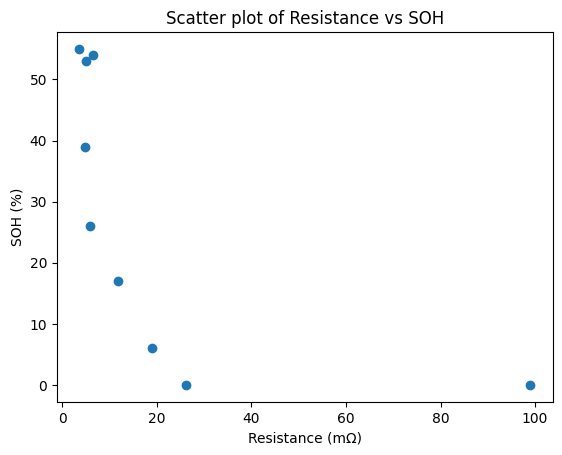

In [14]:
plt.scatter(df_battery["내부저항(mΩ)"], df_battery["SOH(%)"])
plt.xlabel("Resistance (mΩ)")
plt.ylabel("SOH (%)")
plt.title("Scatter plot of Resistance vs SOH")
plt.show()

In [22]:
#상관계수 계산
df_battery[["내부저항(mΩ)", "SOH(%)"]].corr()

,내부저항(mΩ),SOH(%)
내부저항(mΩ),1.00000,-0.62944
SOH(%),-0.62944,1.00000


In [17]:
import numpy as np

In [18]:
#polyfit(1차 회귀선), m기울기, b 절편 
m, b = np.polyfit(df_battery["내부저항(mΩ)"],
                  df_battery["SOH(%)"], 1)


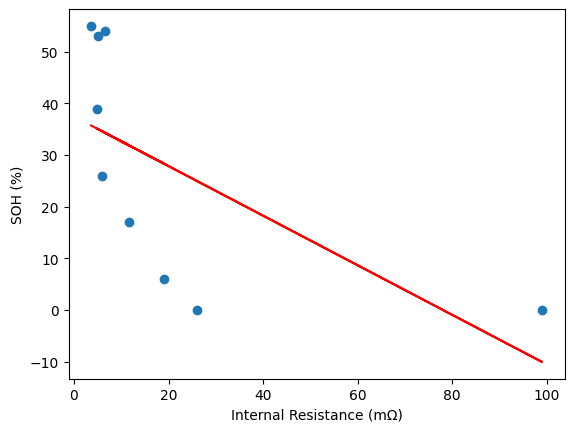

In [19]:
plt.scatter(df_battery["내부저항(mΩ)"],
            df_battery["SOH(%)"])

plt.plot(df_battery["내부저항(mΩ)"],
         m * df_battery["내부저항(mΩ)"] + b,
         color="red")

plt.xlabel("Internal Resistance (mΩ)")
plt.ylabel("SOH (%)")

plt.show()

# 내부저항 분석 결과

# 목적
- 내부저항과 SOH 관계를 확인한다.

# 결과
- 피어슨 상관계수는 -0.629로 나타났다.

# 해석
- 내부저항이 증가할 수록 SOH가 감소하는 경향을 확인하였다.

# 한계
- 표본 수가 9개로 적어 추가적인 검증이 필요하다.

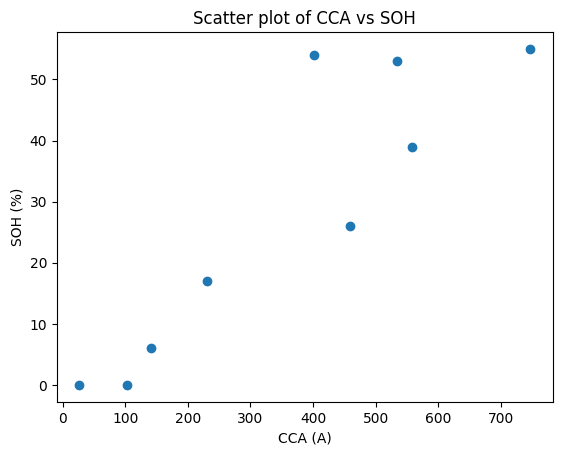

In [20]:
plt.scatter(df_battery["CCA(A)"], df_battery["SOH(%)"])
plt.xlabel("CCA (A)")
plt.ylabel("SOH (%)")
plt.title("Scatter plot of CCA vs SOH")
plt.show()

In [21]:
df_battery[["CCA(A)", "SOH(%)"]].corr()

,CCA(A),SOH(%)
CCA(A),1.000000,0.898007
SOH(%),0.898007,1.000000


In [23]:
m, b = np.polyfit(df_battery["CCA(A)"],
                  df_battery["SOH(%)"], 1)

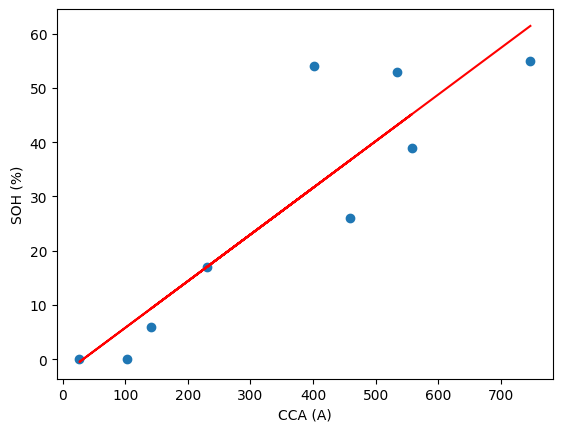

In [24]:
plt.scatter(df_battery["CCA(A)"],
            df_battery["SOH(%)"])

plt.plot(df_battery["CCA(A)"],
         m * df_battery["CCA(A)"] + b,
         color="red")

plt.xlabel("CCA (A)")
plt.ylabel("SOH (%)")

plt.show()

In [ ]:
# CCA 분석 결과

# 목적
- CCA와 SOH 관계를 확인한다.

# 결과
- 피어슨 상관계수는 0.898로 나타났다.

# 해석
- CCA가 증가할 수록 SOH가 증가하는 경향을 확인하였다.

# 한계
- 표본 수가 9개로 적어 추가적인 검증이 필요하다.